In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [9]:
# ---- Convex polygon ----
def generate_convex_shape(center, scale=0.2, n_vertices=12):
    pts = np.random.rand(n_vertices, 2) * scale + center
    hull = ConvexHull(pts)
    return pts[hull.vertices]


# ---- Sample boundary points uniformly along edges ----
def sample_boundary(polygon, n_samples=200):
    edges = np.roll(polygon, -1, axis=0) - polygon
    lengths = np.linalg.norm(edges, axis=1)
    total_length = np.sum(lengths)

    samples = []
    for i, edge in enumerate(edges):
        count = int(n_samples * (lengths[i] / total_length))
        for t in np.linspace(0, 1, count, endpoint=False):
            samples.append(polygon[i] + t * edge)
    return np.array(samples)

In [29]:
# ----- Create multiple shapes -----
centers = np.array([[0.3,0.3],[0.7,0.3],[0.5,0.7]])
polygons = [generate_convex_shape(c, scale=0.25) for c in centers]

target_list = [sample_boundary(poly, 200) for poly in polygons]
target_np = np.vstack(target_list)

# Source random cloud
source_np = np.random.uniform(0, 1, (600, 2))

target = torch.tensor(target_np, dtype=torch.float32, device=device)
source = torch.tensor(source_np, dtype=torch.float32, device=device)


In [30]:
if target.shape[0] > source.shape[0]:
	target = target[:source.shape[0]]

else:
	source = source[:target.shape[0]]

In [31]:
source.requires_grad = True

In [11]:
def sdf_convex_polygon(points, polygon):
    polygon = torch.tensor(polygon, dtype=torch.float32, device=points.device)

    edges = polygon.roll(-1, dims=0) - polygon
    normals = torch.stack([-edges[:,1], edges[:,0]], dim=1)
    normals = normals / torch.norm(normals, dim=1, keepdim=True)

    rel = points.unsqueeze(1) - polygon.unsqueeze(0)
    distances = torch.sum(rel * normals.unsqueeze(0), dim=2)

    return torch.max(distances, dim=1).values


def sdf_union(points, polygons):
    sdf_vals = [sdf_convex_polygon(points, poly) for poly in polygons]
    sdf_vals = torch.stack(sdf_vals, dim=1)
    return torch.min(sdf_vals, dim=1).values


In [12]:
def chamfer_loss(x, y):
    x_exp = x.unsqueeze(1)          # (N,1,2)
    y_exp = y.unsqueeze(0)          # (1,M,2)
    dist = torch.sum((x_exp - y_exp)**2, dim=2)

    loss_xy = torch.mean(torch.min(dist, dim=1).values)
    loss_yx = torch.mean(torch.min(dist, dim=0).values)

    return loss_xy + loss_yx


In [32]:
optimizer = torch.optim.Adam([source], lr=5e-3)

noise_initial = 0.02
noise_final = 0.001
num_epochs = 1200

for epoch in range(num_epochs):

    optimizer.zero_grad()

    # --------- Chamfer Loss ---------
    x_exp = source.unsqueeze(1)
    y_exp = target.unsqueeze(0)
    dist = torch.sum((x_exp - y_exp)**2, dim=2)

    loss_xy = torch.mean(torch.min(dist, dim=1).values)
    loss_yx = torch.mean(torch.min(dist, dim=0).values)
    loss = loss_xy + loss_yx

    loss.backward()
    optimizer.step()

    # --------- Tangential Projection Step ---------
    with torch.no_grad():

        # Nearest target for each source (for geometry only)
        nearest_idx = torch.argmin(dist, dim=1)
        nearest_target = target[nearest_idx]

        diff = source - nearest_target
        norm = torch.norm(diff, dim=1, keepdim=True) + 1e-8
        normal = diff / norm

        # Rotate 90 degrees
        tangent = torch.stack([-normal[:,1], normal[:,0]], dim=1)

        # Remove normal component
        tangential_component = torch.sum(diff * tangent, dim=1, keepdim=True) * tangent
        source[:] = nearest_target + tangential_component

        # --------- Add Decaying Noise ---------
        noise_scale = noise_initial * (1 - epoch / num_epochs) + \
                      noise_final * (epoch / num_epochs)

        source += noise_scale * torch.randn_like(source)

    if epoch % 200 == 0:
        print(epoch, loss.item())


0 0.03999008238315582
200 0.0003322143747936934
400 0.0002148686326108873
600 0.00013553665485233068
800 7.365492638200521e-05
1000 3.3047581382561475e-05


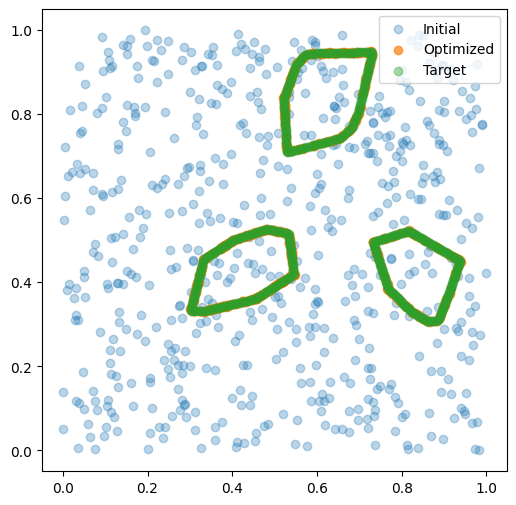

In [33]:
plt.figure(figsize=(6,6))
plt.scatter(source_np[:,0], source_np[:,1], alpha=0.3, label="Initial")

plt.scatter(source.detach().cpu()[:,0],
            source.detach().cpu()[:,1],
            alpha=0.7, label="Optimized")

plt.scatter(target_np[:,0], target_np[:,1],
            alpha=0.4, label="Target")

plt.legend()
plt.show()
